## Model

In [1]:
# HIGH_COST Logit Model — CRSS 2023 (BINNED VERSION, NO WEATHER)
# Change requested: DROP "Unknown" vehicle age by dropping missing/invalid MOD_YEAR
# - Outcome HIGH_COST: (TOWED in {6,7}) OR (ROLLOVER==3) OR (FIRE_EXP==1) OR (DEFORMED==6)
# - Speed: median imputation, then SPEED_BIN (no SP_MISSING in the model)
# - Vehicle age: VEH_AGE = 2023 - MOD_YEAR, binned; rows with missing/invalid MOD_YEAR are dropped
# - Driver: AGE_BIN, SEX, UNBUCKLED (+ BELT_UNKNOWN), DRUGS (+ DRUGS_UNKNOWN)
# - Accident: NIGHT, LIGHT, REGION_USE, URBAN_USE, ALCOHOL (+ ALCOHOL_UNKNOWN)
# - Controls: BODY, P2, VSUR
# - Cluster-robust SE by crash (CASENUM)
#
# NOTE: statsmodels may warn about cluster cov with var_weights; we silence it.

import warnings
warnings.filterwarnings("ignore", message=".*cov_type.*var_weights.*")

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path

# =========================================================
# 0) PATH + LOAD
# =========================================================

acc = pd.read_csv("accident.csv", low_memory=False)
veh = pd.read_csv("vehicle.csv",  low_memory=False)
per = pd.read_csv("person.csv",   low_memory=False)

# =========================================================
# helpers
# =========================================================
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def topn_other(series, topn):
    vc = series.value_counts(dropna=False)
    top = vc.head(topn).index
    return series.where(series.isin(top), "Other")

def to_num(s):
    return pd.to_numeric(s, errors="coerce")

def debug_find_cols(df, keywords):
    kw = tuple(k.lower() for k in keywords)
    return [c for c in df.columns if any(k in c.lower() for k in kw)]

# =========================================================
# 1) FIND REQUIRED COLUMNS (NO WEATHER)
# =========================================================
# --- accident.csv ---
hour_col   = pick_col(acc, ["HOUR_IM", "HOUR"])
light_col  = pick_col(acc, ["LGTCON_IMNAME", "LGT_CONDNAME", "LGT_COND_IMNAME", "LGT_COND"])
region_col = pick_col(acc, ["REGIONNAME", "REGION"])
urban_col  = pick_col(acc, ["URBANICITYNAME", "URBANICITY"])
alcohol_col = pick_col(acc, ["ALCOHOL_IM", "ALCOHOL_IMNAME", "ALCOHOL", "ALCOHOLNAME"])

for name, col in [("hour", hour_col), ("light", light_col), ("region", region_col),
                  ("urban", urban_col), ("alcohol", alcohol_col)]:
    if col is None:
        if name == "alcohol":
            print("accident.csv columns containing 'ALC':", debug_find_cols(acc, ["ALC", "ALCO"]))
        raise ValueError(f"accident.csv: cannot find column for '{name}'")

# --- vehicle.csv ---
vehno_col  = pick_col(veh, ["VEH_NO"])
trav_col   = pick_col(veh, ["TRAV_SP"])
p2_col     = pick_col(veh, ["P_CRASH2NAME", "P_CRASH2"])
vsur_col   = pick_col(veh, ["VSURCONDNAME", "VSURCOND"])
body_col   = pick_col(veh, ["ICFINALBODYNAME", "BODY_TYPNAME", "VPICBODYCLASSNAME", "BODY_TYP"])
modyr_col  = pick_col(veh, ["MOD_YEAR"])
w_col      = pick_col(veh, ["WEIGHT"])

towed_col  = pick_col(veh, ["TOWED"])
roll_col   = pick_col(veh, ["ROLLOVER"])
fire_col   = pick_col(veh, ["FIRE_EXP"])
deform_col = pick_col(veh, ["DEFORMED"])

for name, col in [("veh_no", vehno_col), ("trav_sp", trav_col), ("p_crash2", p2_col),
                  ("vsurcond", vsur_col), ("body", body_col), ("mod_year", modyr_col),
                  ("weight", w_col), ("towed", towed_col), ("rollover", roll_col),
                  ("fire", fire_col), ("deformed", deform_col)]:
    if col is None:
        raise ValueError(f"vehicle.csv: cannot find column for '{name}'")

# --- person.csv (drivers) ---
vehno_p  = pick_col(per, ["VEH_NO"])
pertyp   = pick_col(per, ["PER_TYP"])
age_col  = pick_col(per, ["AGE_IM", "AGE"])
sex_col  = pick_col(per, ["SEX_IMNAME", "SEXNAME", "SEX_IM", "SEX"])
rest_col = pick_col(per, ["RESTUSE_IMNAME", "REST_USE_IMNAME", "REST_USENAME", "RESTUSE"])
drugs_col = pick_col(per, ["DRUGS_IM", "DRUGS_IMNAME", "DRUGS", "DRUGSNAME"])

for name, col in [("veh_no", vehno_p), ("per_typ", pertyp), ("age", age_col),
                  ("sex", sex_col), ("rest", rest_col), ("drugs", drugs_col)]:
    if col is None:
        if name == "drugs":
            print("person.csv columns containing 'DRUG':", debug_find_cols(per, ["DRUG"]))
        raise ValueError(f"person.csv: cannot find column for '{name}'")

# =========================================================
# 2) VEHICLE-LEVEL BASE + HIGH_COST
# =========================================================
v = veh[[
    "CASENUM", vehno_col, trav_col, p2_col, vsur_col,
    body_col, modyr_col, w_col,
    towed_col, roll_col, fire_col, deform_col
]].copy()

v[vehno_col] = to_num(v[vehno_col])
v = v.dropna(subset=["CASENUM", vehno_col]).copy()

# weights
v["W"] = to_num(v[w_col])
v = v[v["W"].notna() & (v["W"] > 0)].copy()

# outcome flags (numeric codes)
v["TOWED_c"] = to_num(v[towed_col])
v["ROLL_c"]  = to_num(v[roll_col])
v["FIRE_c"]  = to_num(v[fire_col])
v["DEF_c"]   = to_num(v[deform_col])

# 2022+ towing commonly: 6=Towed, 7=Towed unknown reason
flag_towed  = v["TOWED_c"].isin([6, 7])
flag_roll   = v["ROLL_c"].eq(3)   # 2022+ rollover: 3=Rollover
flag_fire   = v["FIRE_c"].eq(1)   # fire: 1=Yes
flag_deform = v["DEF_c"].eq(6)    # deformed: 6=Disabling damage

v["HIGH_COST"] = (flag_towed | flag_roll | flag_fire | flag_deform).astype(int)

print(f"HIGH_COST rate (unweighted): {v['HIGH_COST'].mean():.3f}")
print(f"HIGH_COST=1: {v['HIGH_COST'].sum():,}  |  HIGH_COST=0: {(v['HIGH_COST']==0).sum():,}")

# =========================================================
# 3) SPEED: build TRAV_SP_REAL and impute median (for binning)
# =========================================================
v["TRAV_SP_RAW"]  = to_num(v[trav_col])
v["TRAV_SP_REAL"] = np.where(
    (v["TRAV_SP_RAW"] >= 1) & (v["TRAV_SP_RAW"] <= 151),
    v["TRAV_SP_RAW"],
    np.nan
)
median_sp = v["TRAV_SP_REAL"].median()
v["TRAV_SP_REAL"] = v["TRAV_SP_REAL"].fillna(median_sp)

print("\nSpeed imputation:")
print(f"  Median speed used for imputation: {median_sp:.1f} mph")

# =========================================================
# 4) VEHICLE COVARIATES
# =========================================================
v["P2"]       = v[p2_col].fillna("Unknown").astype("object")
v["VSUR"]     = v[vsur_col].fillna("Unknown").astype("object")
v["BODY"]     = v[body_col].fillna("Unknown").astype("object")
v["MOD_YEAR"] = to_num(v[modyr_col])

# =========================================================
# 5) CRASH-LEVEL (accident.csv): NIGHT/LIGHT/REGION/URBAN + ALCOHOL
# =========================================================
a = acc[["CASENUM", hour_col, light_col, region_col, urban_col, alcohol_col]].copy()
a[hour_col] = to_num(a[hour_col])
a["NIGHT"]  = ((a[hour_col] >= 20) | (a[hour_col] <= 5)).astype(int)

a = a.rename(columns={
    light_col:  "LIGHT",
    region_col: "REGION_USE",
    urban_col:  "URBAN_USE",
})

# ALCOHOL codes (2016+): 1=yes, 2=no, 8=n/a, 9=unknown
alc_num = to_num(a[alcohol_col])
a["ALCOHOL_INV"] = np.where(alc_num == 1, 1,
                     np.where(alc_num == 2, 0, np.nan))
a["ALCOHOL_UNKNOWN"] = a["ALCOHOL_INV"].isna().astype(int)
a["ALCOHOL_INV"] = a["ALCOHOL_INV"].fillna(0).astype(int)

for c in ["LIGHT", "REGION_USE", "URBAN_USE"]:
    a[c] = a[c].fillna("Unknown").astype("object")

a = a[["CASENUM", "NIGHT", "LIGHT", "REGION_USE", "URBAN_USE", "ALCOHOL_INV", "ALCOHOL_UNKNOWN"]].drop_duplicates("CASENUM")
v = v.merge(a, on="CASENUM", how="inner")

# =========================================================
# 6) DRIVER-LEVEL (person.csv): drivers only
# =========================================================
d = per[["CASENUM", vehno_p, pertyp, age_col, sex_col, rest_col, drugs_col]].copy()
d[vehno_p] = to_num(d[vehno_p])
d = d.dropna(subset=["CASENUM", vehno_p]).copy()
d = d[d[pertyp] == 1].copy()
d = d.rename(columns={vehno_p: "VEH_NO_JOIN"})

d["AGE"]  = to_num(d[age_col])
d["SEX"]  = d[sex_col].fillna("Unknown").astype("object")
d["REST"] = d[rest_col].fillna("Unknown").astype("object")

# UNBUCKLED (robust text search)
r = d["REST"].astype(str).str.lower()
d["UNBUCKLED"] = np.where(
    r.str.contains("not used|none used|unrestrained|no belt", regex=True, na=False), 1,
    np.where(r.str.contains("lap|shoulder|used|restrained", regex=True, na=False), 0, np.nan)
)

# DRUGS codes (2018+): 0=no, 1=yes, 8/9 missing-ish
drug_num = to_num(d[drugs_col])
d["DRUGS_INV"] = np.where(drug_num == 1, 1,
                   np.where(drug_num == 0, 0, np.nan))
d["DRUGS_UNKNOWN"] = d["DRUGS_INV"].isna().astype(int)
d["DRUGS_INV"] = d["DRUGS_INV"].fillna(0).astype(int)

d = d[["CASENUM", "VEH_NO_JOIN", "AGE", "SEX", "UNBUCKLED", "DRUGS_INV", "DRUGS_UNKNOWN"]].copy()

v = v.rename(columns={vehno_col: "VEH_NO_JOIN"})
v = v.merge(d, on=["CASENUM", "VEH_NO_JOIN"], how="left")

# =========================================================
# 7) CLEAN — keep missing belt via dummy; DROP missing/invalid MOD_YEAR (removes VEH_AGE Unknown)
# =========================================================
# First: belt unknown handling
v["UNBUCKLED"] = v["UNBUCKLED"].fillna(-1)
v["BELT_UNKNOWN"] = (v["UNBUCKLED"] == -1).astype(int)
v["UNBUCKLED"] = v["UNBUCKLED"].replace(-1, 0).astype(int)

# Drop rows where MOD_YEAR is missing/invalid BEFORE vehicle-age binning
# Reasonable bounds for model year
v = v[v["MOD_YEAR"].notna()].copy()
v = v[(v["MOD_YEAR"] >= 1960) & (v["MOD_YEAR"] <= 2023)].copy()

required_cols = [
    "HIGH_COST", "W",
    "NIGHT", "LIGHT", "REGION_USE", "URBAN_USE",
    "ALCOHOL_INV", "ALCOHOL_UNKNOWN",
    "TRAV_SP_REAL",
    "MOD_YEAR", "BODY", "P2", "VSUR",
    "AGE", "SEX",
    "DRUGS_INV", "DRUGS_UNKNOWN",
    "UNBUCKLED", "BELT_UNKNOWN",
]
v = v.dropna(subset=required_cols).copy()

# =========================================================
# 8) BINS: SPEED_BIN, AGE_BIN, VEH_AGE_BIN (NO Unknown category now)
# =========================================================
v["SPEED_BIN"] = pd.cut(
    v["TRAV_SP_REAL"],
    bins=[0, 15, 30, 45, 60, 75, 200],
    labels=["0-15", "16-30", "31-45", "46-60", "61-75", "75+"],
    right=True,
    include_lowest=True
)

v["AGE_BIN"] = pd.cut(
    v["AGE"],
    bins=[0, 20, 35, 50, 65, 120],
    labels=["<21", "21-35", "36-50", "51-65", "65+"],
    right=True,
    include_lowest=True
)

v["VEH_AGE"] = 2023 - v["MOD_YEAR"]
# sanity: drop unrealistic vehicle ages (optional but safe)
v = v[(v["VEH_AGE"] >= 0) & (v["VEH_AGE"] <= 50)].copy()

v["VEH_AGE_BIN"] = pd.cut(
    v["VEH_AGE"],
    bins=[-0.1, 2, 5, 10, 15, 25, 50],
    labels=["0-2", "3-5", "6-10", "11-15", "16-25", "26+"],
    right=True,
    include_lowest=True
)

# drop any remaining NA bins (should be minimal)
v = v.dropna(subset=["SPEED_BIN", "AGE_BIN", "VEH_AGE_BIN"]).copy()

# =========================================================
# 9) Reduce category cardinality (NO WEATHER)
# =========================================================
v["LIGHT"]      = topn_other(v["LIGHT"].astype("object"), 6)
v["REGION_USE"] = topn_other(v["REGION_USE"].astype("object"), 5)
v["URBAN_USE"]  = topn_other(v["URBAN_USE"].astype("object"), 4)
v["P2"]         = topn_other(v["P2"].astype("object"), 12)
v["VSUR"]       = topn_other(v["VSUR"].astype("object"), 7)
v["BODY"]       = topn_other(v["BODY"].astype("object"), 12)
v["SEX"]        = topn_other(v["SEX"].astype("object"), 4)

# =========================================================
# 10) Final diagnostics
# =========================================================
print(f"\n{'='*55}")
print(f"Final sample: N = {len(v):,} vehicle-level observations")
print(f"HIGH_COST rate (unweighted): {v['HIGH_COST'].mean():.3f}")
w_rate = float((v["HIGH_COST"] * v["W"]).sum() / v["W"].sum())
print(f"HIGH_COST rate (weighted):   {w_rate:.3f}")
print(f"BELT_UNKNOWN rate:           {v['BELT_UNKNOWN'].mean():.3f}")
print(f"ALCOHOL_UNKNOWN rate:        {v['ALCOHOL_UNKNOWN'].mean():.3f}")
print(f"DRUGS_UNKNOWN rate:          {v['DRUGS_UNKNOWN'].mean():.3f}")
print(f"{'='*55}\n")

# =========================================================
# 11) Logit model (cluster by CASENUM) — BINNED + NO Unknown VEH_AGE
# =========================================================
bin_formula = (
    "HIGH_COST ~ "
    "C(SPEED_BIN) + NIGHT + "
    "C(VEH_AGE_BIN) + C(BODY) + "
    "UNBUCKLED + BELT_UNKNOWN + C(AGE_BIN) + C(SEX) + "
    "ALCOHOL_INV + ALCOHOL_UNKNOWN + "
    "DRUGS_INV + DRUGS_UNKNOWN + "
    "C(LIGHT) + C(REGION_USE) + C(URBAN_USE) + "
    "C(P2) + C(VSUR)"
)

print("Using formula:\n", bin_formula)
print("\nFitting logit with var_weights + cluster-robust SE (CASENUM)...\n")

m_bin = smf.glm(
    formula=bin_formula,
    data=v,
    family=sm.families.Binomial(),
    var_weights=v["W"]
).fit(cov_type="cluster", cov_kwds={"groups": v["CASENUM"]})

print(m_bin.summary())

# =========================================================
# 12) McFadden pseudo R² + significant OR table
# =========================================================
pseudo_r2 = 1 - m_bin.llf / m_bin.llnull
print(f"\nMcFadden Pseudo R²: {pseudo_r2:.4f}")
print(f"N vehicles in model: {len(v):,}")
print(f"HIGH_COST rate (weighted): {w_rate:.4f}")

or_table = pd.DataFrame({
    "coef": m_bin.params,
    "OR": np.exp(m_bin.params),
    "OR_lo": np.exp(m_bin.conf_int()[0]),
    "OR_hi": np.exp(m_bin.conf_int()[1]),
    "p_value": m_bin.pvalues,
}).round(4)

or_table["significant"] = or_table["p_value"] < 0.05
print("\n--- Significant Odds Ratios ---")
print(or_table[or_table["significant"]].sort_values("OR", ascending=False).to_string())

HIGH_COST rate (unweighted): 0.406
HIGH_COST=1: 35,498  |  HIGH_COST=0: 51,963

Speed imputation:
  Median speed used for imputation: 30.0 mph

Final sample: N = 82,731 vehicle-level observations
HIGH_COST rate (unweighted): 0.425
HIGH_COST rate (weighted):   0.360
BELT_UNKNOWN rate:           0.078
ALCOHOL_UNKNOWN rate:        0.352
DRUGS_UNKNOWN rate:          0.511

Using formula:
 HIGH_COST ~ C(SPEED_BIN) + NIGHT + C(VEH_AGE_BIN) + C(BODY) + UNBUCKLED + BELT_UNKNOWN + C(AGE_BIN) + C(SEX) + ALCOHOL_INV + ALCOHOL_UNKNOWN + DRUGS_INV + DRUGS_UNKNOWN + C(LIGHT) + C(REGION_USE) + C(URBAN_USE) + C(P2) + C(VSUR)

Fitting logit with var_weights + cluster-robust SE (CASENUM)...



C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\statsmodels\genmod\generalized_linear_model.py:1655: SpecificationWarning: cov_type not fully supported with var_weights
  warnings.warn('cov_type not fully supported with var_weights',


                 Generalized Linear Model Regression Results                  
Dep. Variable:              HIGH_COST   No. Observations:                82731
Model:                            GLM   Df Residuals:                    82667
Model Family:                Binomial   Df Model:                           63
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.6985e+06
Date:                Wed, 22 Apr 2026   Deviance:                   1.1397e+07
Time:                        20:26:42   Pearson chi2:                 1.03e+07
No. Iterations:                     6   Pseudo R-squ. (CS):              1.000
Covariance Type:              cluster                                         
                                                                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

## Box-Tidwell test

In [2]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Use the raw continuous variables (not the binned ones in the model)
# Add interaction terms: x * ln(x) for each continuous predictor
bt = v.copy()
bt = bt[bt['TRAV_SP_REAL'] > 0]  # log requires positive values
bt = bt[bt['AGE'] > 0]
bt = bt[bt['VEH_AGE'] > 0]

bt['SPEED_ln']   = bt['TRAV_SP_REAL'] * np.log(bt['TRAV_SP_REAL'])
bt['AGE_ln']     = bt['AGE'] * np.log(bt['AGE'])
bt['VEH_AGE_ln'] = bt['VEH_AGE'] * np.log(bt['VEH_AGE'])

bt_formula = (
    "HIGH_COST ~ TRAV_SP_REAL + SPEED_ln + "
    "AGE + AGE_ln + "
    "VEH_AGE + VEH_AGE_ln"
)

bt_model = smf.glm(
    formula=bt_formula,
    data=bt,
    family=sm.families.Binomial(),
    var_weights=bt['W']
).fit()

print(bt_model.summary())
print("\n--- Box-Tidwell: Interaction terms (p < 0.05 → non-linearity) ---")
bt_results = pd.DataFrame({
    'coef':  bt_model.params,
    'p_val': bt_model.pvalues
})
print(bt_results.loc[['SPEED_ln', 'AGE_ln', 'VEH_AGE_ln']])

                 Generalized Linear Model Regression Results                  
Dep. Variable:              HIGH_COST   No. Observations:                78894
Model:                            GLM   Df Residuals:                    78887
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -6.2687e+06
Date:                Wed, 22 Apr 2026   Deviance:                   1.2537e+07
Time:                        20:32:28   Pearson chi2:                 9.91e+06
No. Iterations:                     5   Pseudo R-squ. (CS):             0.9961
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.9614      0.009   -101.943   

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


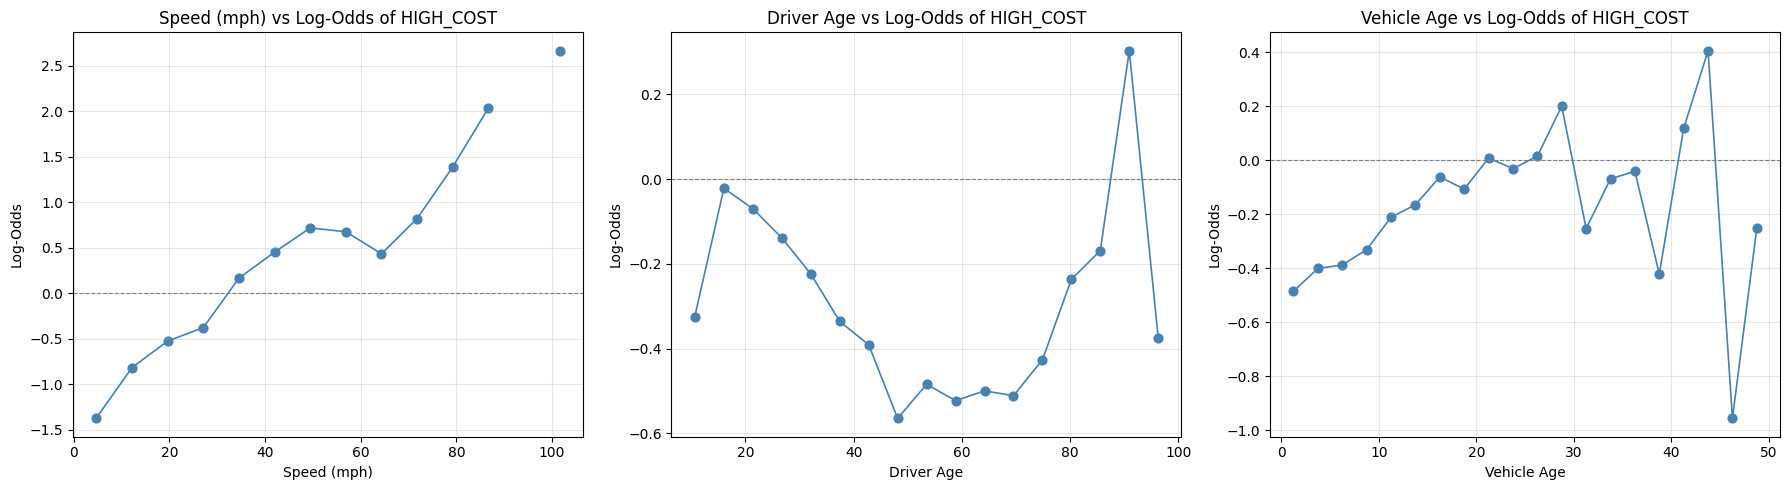

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cont_vars = [
    ('TRAV_SP_REAL', 'Speed (mph)',    v['TRAV_SP_REAL'] <= 151),
    ('AGE',          'Driver Age',     v['AGE'] <= 120),
    ('VEH_AGE',      'Vehicle Age',    (v['VEH_AGE'] >= 0) & (v['VEH_AGE'] <= 50)),
]

for i, (var, label, mask) in enumerate(cont_vars):
    plot_df = v[mask].copy()

    # Bin the continuous variable into ~20 equal-width groups
    plot_df['_bin'] = pd.cut(plot_df[var], bins=20)
    grp = plot_df.groupby('_bin', observed=True)['HIGH_COST'].mean()

    # Convert proportion to log-odds
    log_odds = np.log(grp / (1 - grp))
    bin_mids  = grp.index.map(lambda x: x.mid)

    axes[i].scatter(bin_mids, log_odds, color='steelblue', s=40)
    axes[i].plot(bin_mids, log_odds, color='steelblue', linewidth=1.2)
    axes[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[i].set_title(f'{label} vs Log-Odds of HIGH_COST')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Log-Odds')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

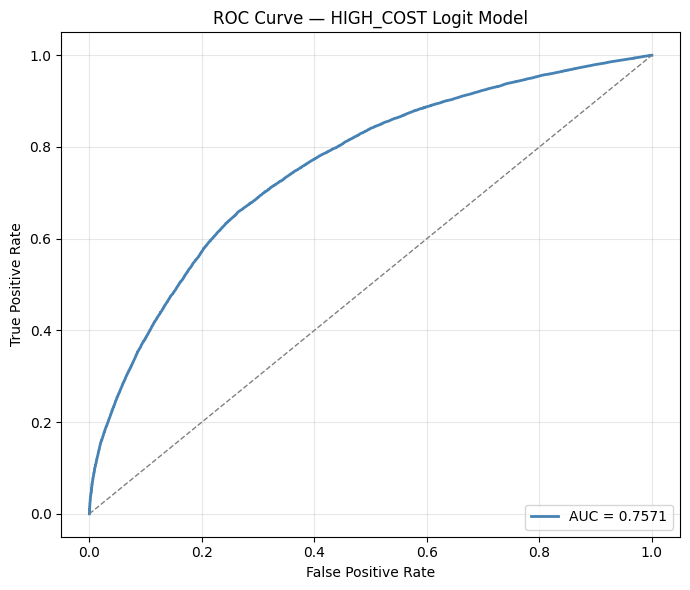

AUC: 0.7571


In [4]:
from sklearn.metrics import roc_curve, roc_auc_score

y_true  = v['HIGH_COST']
y_pred  = m_bin.predict(v)   # predicted probabilities

fpr, tpr, thresholds = roc_curve(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_pred)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — HIGH_COST Logit Model')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {auc_score:.4f}")

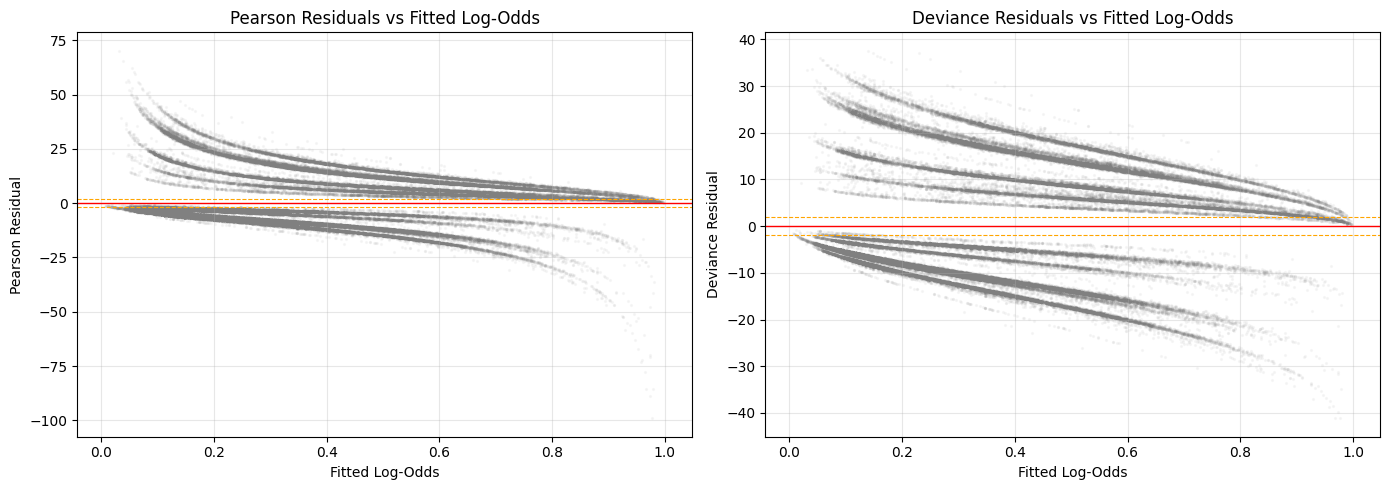

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pearson_resid  = m_bin.resid_pearson
deviance_resid = m_bin.resid_deviance
fitted         = m_bin.fittedvalues   # linear predictor (log-odds)

# Pearson residuals
axes[0].scatter(fitted, pearson_resid, alpha=0.05, s=2, color='gray')
axes[0].axhline(0,  color='red', linewidth=1)
axes[0].axhline(2,  color='orange', linestyle='--', linewidth=0.8)
axes[0].axhline(-2, color='orange', linestyle='--', linewidth=0.8)
axes[0].set_title('Pearson Residuals vs Fitted Log-Odds')
axes[0].set_xlabel('Fitted Log-Odds')
axes[0].set_ylabel('Pearson Residual')
axes[0].grid(True, alpha=0.3)

# Deviance residuals
axes[1].scatter(fitted, deviance_resid, alpha=0.05, s=2, color='gray')
axes[1].axhline(0,  color='red', linewidth=1)
axes[1].axhline(2,  color='orange', linestyle='--', linewidth=0.8)
axes[1].axhline(-2, color='orange', linestyle='--', linewidth=0.8)
axes[1].set_title('Deviance Residuals vs Fitted Log-Odds')
axes[1].set_xlabel('Fitted Log-Odds')
axes[1].set_ylabel('Deviance Residual')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF needs a plain design matrix (no clustering, no weights)
# Build it from the same formula using dmatrices
from patsy import dmatrices

_, X_vif = dmatrices(
    bin_formula,
    data=v,
    return_type='dataframe'
)

vif_df = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, j) for j in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_df.to_string(index=False))

                                                                                   Variable         VIF
                                                                                  Intercept 2574.956995
                                                                  C(BODY)[T.Not Applicable]   30.416590
                                                                           C(BODY)[T.Truck]   12.554831
                                                                          C(BODY)[T.Pickup]    6.385513
                                                                             C(P2)[T.Other]    4.737134
                                                                             C(BODY)[T.Van]    4.694015
                                     C(P2)[T.Traveling in same direction with higher speed]    3.622056
                                                                       C(LIGHT)[T.Daylight]    2.931462
                                                                

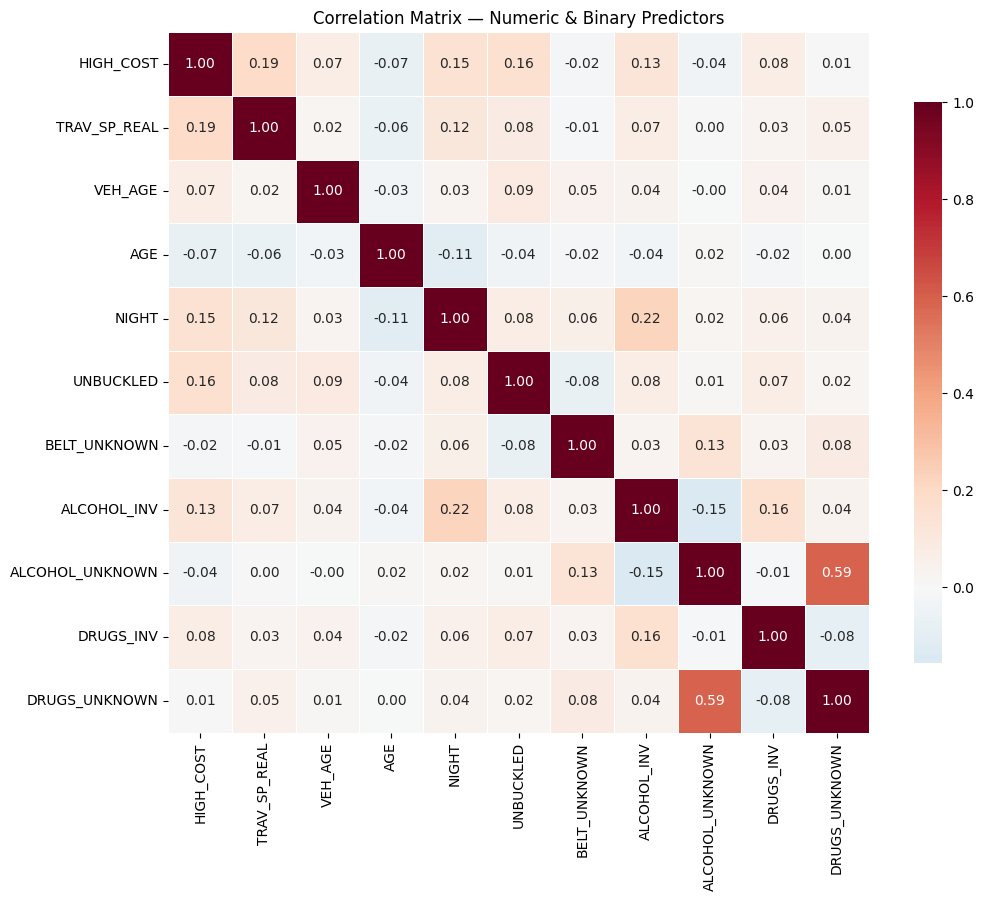

In [7]:
import seaborn as sns

# Select numeric/binary variables only (not the bins — those are categorical)
corr_vars = [
    'HIGH_COST', 'TRAV_SP_REAL', 'VEH_AGE', 'AGE',
    'NIGHT', 'UNBUCKLED', 'BELT_UNKNOWN',
    'ALCOHOL_INV', 'ALCOHOL_UNKNOWN', 'DRUGS_INV', 'DRUGS_UNKNOWN'
]

corr_df = v[corr_vars].copy()
corr_matrix = corr_df.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Matrix — Numeric & Binary Predictors')
plt.tight_layout()
plt.show()